<a href="https://colab.research.google.com/github/p162577-dotcom/E-commerce-Customer-Behavior-Analysis-and-Purchase-Prediction-Using-Apache-Pig-Spark-MLlib-and-HBase/blob/main/Sampling_and_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sampling and Visualization for E-commerce Customer Behavior Data

This notebook records the sampling and visualization work used in the final report.  
The original Taobao user behavior dataset is large, so a smaller working subset was created first.  
After the cleaned behavior file was prepared from the Hadoop workflow, this notebook was used to draw the main charts for the report.

The visualizations here are used to support the discussion on user behavior distribution, conversion funnel, time-based activity, buyer imbalance, product category purchases, and model comparison.

## 1. Import Basic Library

I started with `pandas` because the sampling task only needs basic data loading, sampling, and exporting.  
This part is separate from the Hadoop workflow. It is used to prepare a smaller dataset that is easier to handle during development.

In [ ]:
import pandas as pd

## 2. Load the Original Dataset

The original file was loaded to check whether the dataset could be read correctly.  
This cell is mainly for an initial check before creating the smaller sample file.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/final_report/UserBehavior.csv")

## 3. Check the Current Working Directory

I used this step to confirm the folder location before saving the sampled dataset and later visualization outputs.  
This helps avoid saving files into the wrong directory.

In [ ]:
import os

os.getcwd()

'/content'

## 4. Create a 200,000-record Sample

The original dataset is too large for repeated testing in the sandbox environment.  
To make the project easier to run, I sampled the dataset in chunks. This method avoids loading the full file into memory at once.

A fixed random seed was used so that the sampling process is reproducible.

In [ ]:
import pandas as pd

# Read the large CSV file in chunks instead of loading everything at once.
df_iter = pd.read_csv("/content/drive/MyDrive/final_report/UserBehavior.csv", chunksize=100000)

sample_list = []

# Take 10% from each chunk. The random_state keeps the result reproducible.
for chunk in df_iter:
    sample_list.append(chunk.sample(frac=0.1, random_state=42))

# Combine all sampled chunks into one DataFrame.
df = pd.concat(sample_list, ignore_index=True)

# Keep the final sample size at 200,000 records if the sample is larger than needed.
if len(df) > 200000:
    df = df.sample(n=200000, random_state=42)

# Save the sampled dataset for the Hadoop workflow.
df.to_csv("UserBehavior_200k.csv", index=False)

print(f"Final dataset shape: {df.shape}")

Final dataset shape: (200000, 5)


## 5. Load the Cleaned Behavior Data

After the Hadoop/Pig cleaning step, the cleaned behavior file was downloaded and used for visualization.  
The file has no header, so the column names are manually assigned.

The path below follows my local working folder. If the notebook is run on another computer, the file path should be changed accordingly.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Create the image folder if it does not already exist.
os.makedirs("/content/final_report/images", exist_ok=True)

# Load the cleaned behavior data exported from the Hadoop workflow.
df = pd.read_csv(
    "/content/cleaned_behavior.csv",
    header=None,
    names=["user_id", "item_id", "category_id", "behavior_type", "timestamp"]
)

df.head()

,user_id,item_id,category_id,behavior_type,timestamp
0,1,2268318,2520377,pv,1511544070
1,663918,4495607,2975713,pv,1511957048
2,774870,3852551,4466876,pv,1512209361
3,308269,253787,3299155,pv,1512298498
4,420686,5148623,2920476,pv,1512286124


## 6. Basic Data Check

Before drawing charts, I checked the data structure and the number of records.  
This step is useful because wrong column names or missing values would affect all later visualizations.

In [ ]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200001 entries, 0 to 200000
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user_id        200001 non-null  int64 
 1   item_id        200001 non-null  int64 
 2   category_id    200001 non-null  int64 
 3   behavior_type  200001 non-null  object
 4   timestamp      200001 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 7.6+ MB


(200001, 5)

## 7. Check Behavior Type Counts

This quick count gives the first view of user activity.  
It also helps confirm that the cleaned dataset contains only the four expected behavior types.

In [ ]:
df["behavior_type"].value_counts()

,count
behavior_type,
pv,179146
cart,11023
fav,5759
buy,4073


## 8. User Behavior Type Distribution

This bar chart shows how often each user behavior appears in the cleaned dataset.  
It is useful for understanding the overall structure of user activity before looking at conversion or prediction.

In this dataset, page views are expected to be much higher than purchases, which is common in e-commerce platforms.

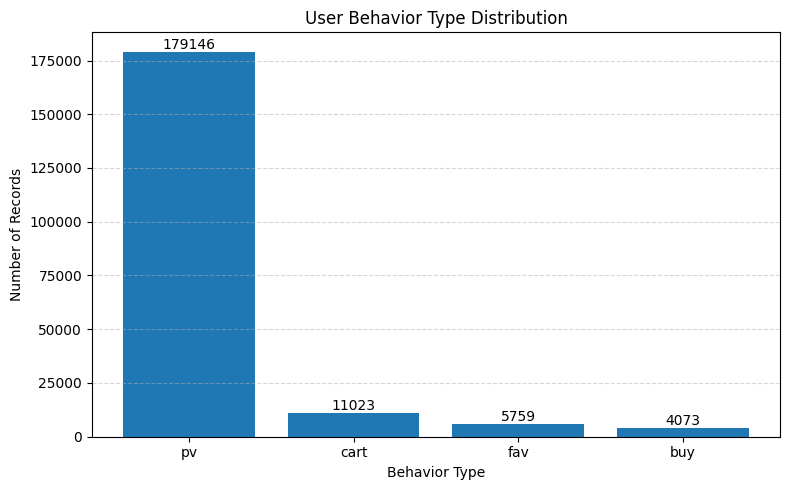

In [ ]:
# Count each behavior type.
behavior_counts = df["behavior_type"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(behavior_counts.index, behavior_counts.values)

plt.title("User Behavior Type Distribution")
plt.xlabel("Behavior Type")
plt.ylabel("Number of Records")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Add labels above each bar to make the values easier to read in the report.
for i, value in enumerate(behavior_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()

# Save the figure for the final report.
plt.savefig("/content/final_report/images/behavior_distribution.png", dpi=300)
plt.show()

## 9. E-commerce Conversion Funnel

The conversion funnel arranges user actions as a simple customer journey:  
page view → add to cart → favorite → purchase.

This chart helps show the drop from browsing to buying.  
It is more business-oriented than the previous behavior distribution chart because it connects the counts to customer conversion.

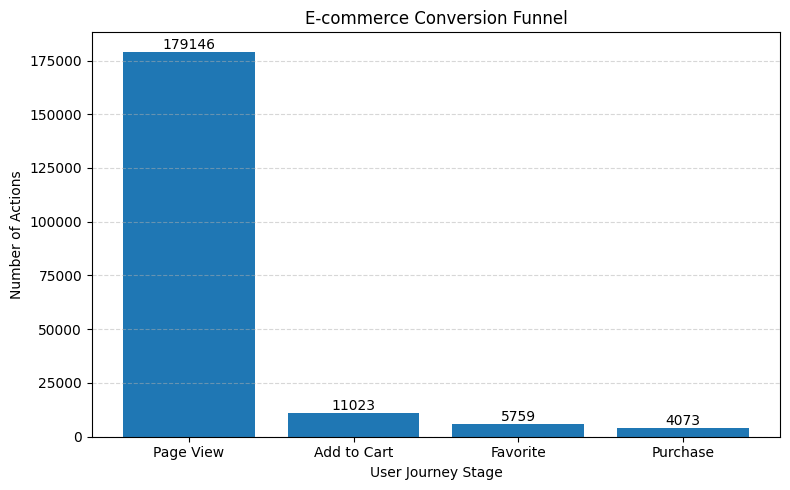

Purchase conversion rate from page view: 2.27 %
Cart-to-purchase ratio: 36.95 %
Favorite-to-purchase ratio: 70.72 %


In [ ]:
# Prepare funnel data based on behavior counts.
funnel_data = pd.DataFrame({
    "Stage": ["Page View", "Add to Cart", "Favorite", "Purchase"],
    "Count": [
        behavior_counts.get("pv", 0),
        behavior_counts.get("cart", 0),
        behavior_counts.get("fav", 0),
        behavior_counts.get("buy", 0)
    ]
})

plt.figure(figsize=(8, 5))
plt.bar(funnel_data["Stage"], funnel_data["Count"])

plt.title("E-commerce Conversion Funnel")
plt.xlabel("User Journey Stage")
plt.ylabel("Number of Actions")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for i, value in enumerate(funnel_data["Count"]):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.savefig("/content/final_report/images/conversion_funnel.png", dpi=300)
plt.show()

# Simple conversion indicators for interpretation.
pv = behavior_counts.get("pv", 0)
cart = behavior_counts.get("cart", 0)
fav = behavior_counts.get("fav", 0)
buy = behavior_counts.get("buy", 0)

print("Purchase conversion rate from page view:", round(buy / pv * 100, 2), "%")
print("Cart-to-purchase ratio:", round(buy / cart * 100, 2), "%")
print("Favorite-to-purchase ratio:", round(buy / fav * 100, 2), "%")

## 10. Hourly User Activity Pattern

The timestamp was converted into datetime format so that user activity could be analyzed by hour.  
This chart is useful for identifying when users are more active on the platform.

The result can support business decisions such as promotion timing and recommendation scheduling.

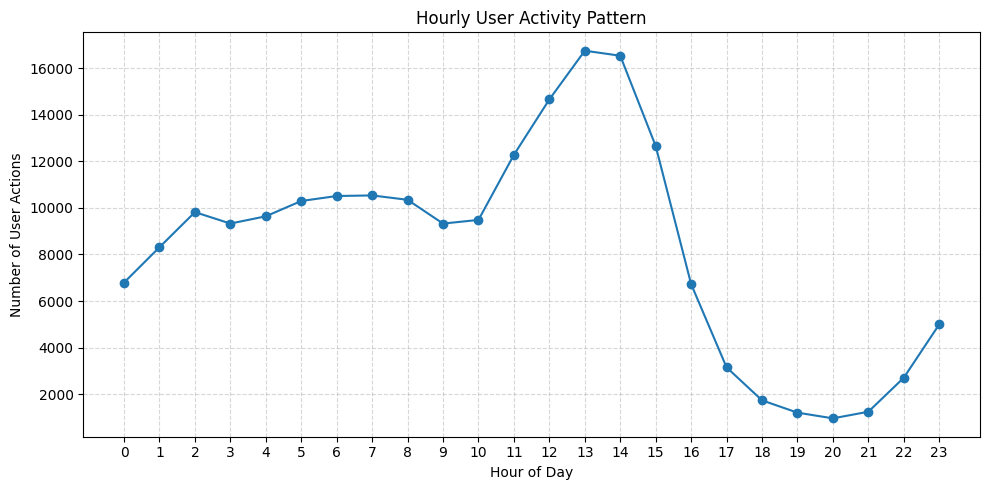

In [ ]:
# Convert Unix timestamp to datetime.
df["datetime"] = pd.to_datetime(df["timestamp"], unit="s")

# Extract time-based fields for analysis.
df["hour"] = df["datetime"].dt.hour
df["date"] = df["datetime"].dt.date
df["day_of_week"] = df["datetime"].dt.day_name()

# Count user actions by hour.
hourly_counts = df.groupby("hour").size()

plt.figure(figsize=(10, 5))
plt.plot(hourly_counts.index, hourly_counts.values, marker="o")

plt.title("Hourly User Activity Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Number of User Actions")
plt.xticks(range(0, 24))
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("/content/final_report/images/hourly_user_activity.png", dpi=300)
plt.show()

## 11. Buyer and Non-buyer Distribution

For purchase prediction, the data needs to be aggregated at the user level.  
A user is labelled as a buyer if the user has at least one purchase action.

This chart shows whether the target classes are balanced.  
The result is important because a highly imbalanced dataset can make accuracy look better than it really is.

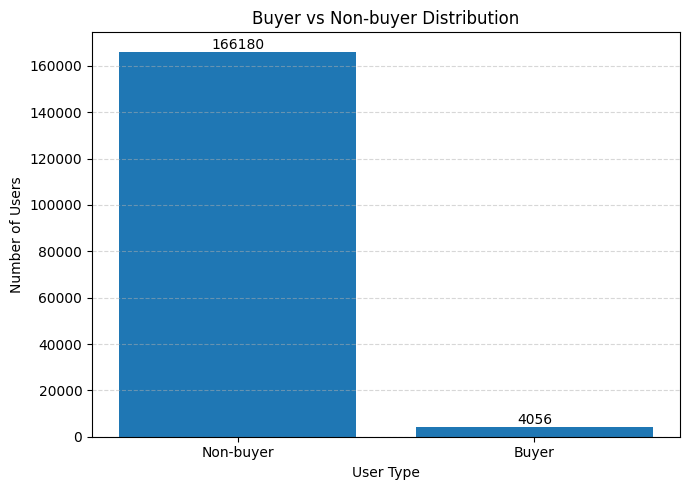

,user_id,pv_count,fav_count,cart_count,buy_count,total_actions,is_buyer
0,1,2,0,0,0,2,0
1,4,1,0,0,0,1,0
2,8,1,0,0,0,1,0
3,29,2,0,0,0,2,0
4,41,1,0,0,0,1,0


In [ ]:
# Aggregate behavior counts for each user.
user_features = df.groupby("user_id").agg(
    pv_count=("behavior_type", lambda x: (x == "pv").sum()),
    fav_count=("behavior_type", lambda x: (x == "fav").sum()),
    cart_count=("behavior_type", lambda x: (x == "cart").sum()),
    buy_count=("behavior_type", lambda x: (x == "buy").sum())
).reset_index()

# Total number of actions for each user.
user_features["total_actions"] = (
    user_features["pv_count"] +
    user_features["fav_count"] +
    user_features["cart_count"] +
    user_features["buy_count"]
)

# Create the buyer label.
user_features["is_buyer"] = user_features["buy_count"].apply(lambda x: 1 if x > 0 else 0)

buyer_counts = user_features["is_buyer"].value_counts().sort_index()
buyer_labels = ["Non-buyer", "Buyer"]

plt.figure(figsize=(7, 5))
plt.bar(buyer_labels, buyer_counts.values)

plt.title("Buyer vs Non-buyer Distribution")
plt.xlabel("User Type")
plt.ylabel("Number of Users")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for i, value in enumerate(buyer_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.savefig("/content/final_report/images/buyer_nonbuyer_distribution.png", dpi=300)
plt.show()

user_features.head()

## 12. Top 10 Product Categories by Purchases

This chart identifies which product categories received the most purchase actions.  
It can be used to discuss product demand, inventory planning, and recommendation priorities.

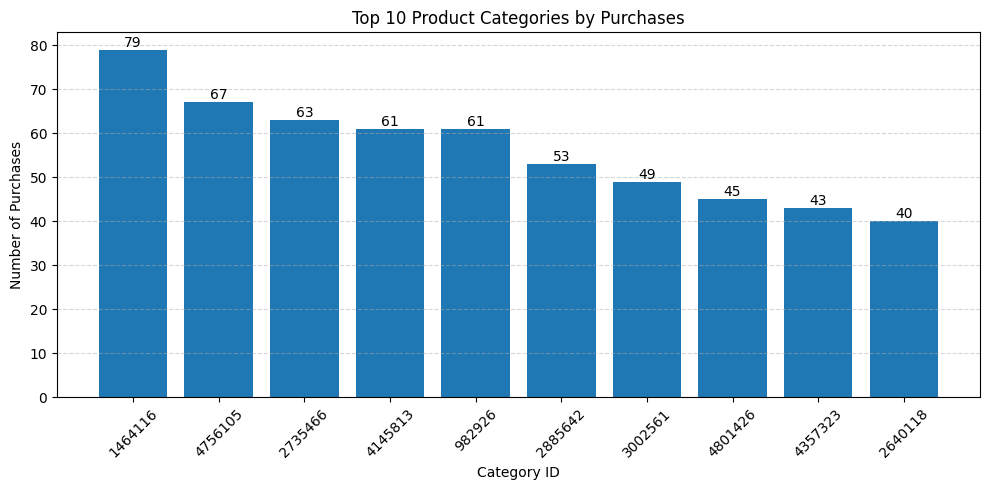

In [ ]:
# Keep only purchase records and count purchases by category.
top_categories = (
    df[df["behavior_type"] == "buy"]
    .groupby("category_id")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.bar(top_categories.index.astype(str), top_categories.values)

plt.title("Top 10 Product Categories by Purchases")
plt.xlabel("Category ID")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for i, value in enumerate(top_categories.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.savefig("/content/final_report/images/top10_purchase_categories.png", dpi=300)
plt.show()

## 13. Machine Learning Model Results

The model scores were obtained from the Spark MLlib output.  
They are entered here manually so that the model comparison can be visualized in the report.

AUC is useful here because the buyer and non-buyer classes are highly imbalanced.

In [ ]:
# Model evaluation results from Spark MLlib.
model_results = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression", "Decision Tree"],
    "AUC": [0.8969, 0.8885, 0.8890],
    "Accuracy": [0.9947, 0.9947, 0.9947],
    "F1-score": [0.9944, 0.9944, 0.9944]
})

model_results

,Model,AUC,Accuracy,F1-score
0,Random Forest,0.8969,0.9947,0.9944
1,Logistic Regression,0.8885,0.9947,0.9944
2,Decision Tree,0.8890,0.9947,0.9944


## 14. Model Performance Comparison

This chart compares the three Spark MLlib models.  
Although the accuracy and F1-score are very close, the AUC values show that Random Forest performs slightly better.

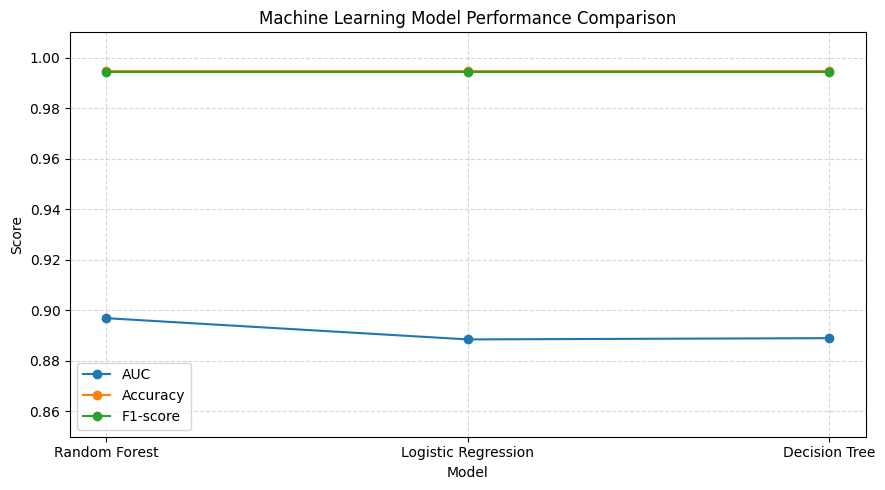

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(model_results["Model"], model_results["AUC"], marker="o", label="AUC")
plt.plot(model_results["Model"], model_results["Accuracy"], marker="o", label="Accuracy")
plt.plot(model_results["Model"], model_results["F1-score"], marker="o", label="F1-score")

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85, 1.01)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig("/content/final_report/images/model_performance_comparison.png", dpi=300)
plt.show()

## 15. Confusion Matrix Summary

The confusion matrix values were also taken from the Spark MLlib output.  
This chart is used as supporting evidence because it shows that most correct predictions come from the non-buyer class.

In [ ]:
# Confusion matrix summary from Spark MLlib output.
confusion_summary = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression", "Decision Tree"],
    "True Buyer": [1013, 1013, 1013],
    "Missed Buyer": [272, 272, 272],
    "Correct Non-buyer": [49656, 49656, 49656]
})

confusion_summary

,Model,True Buyer,Missed Buyer,Correct Non-buyer
0,Random Forest,1013,272,49656
1,Logistic Regression,1013,272,49656
2,Decision Tree,1013,272,49656


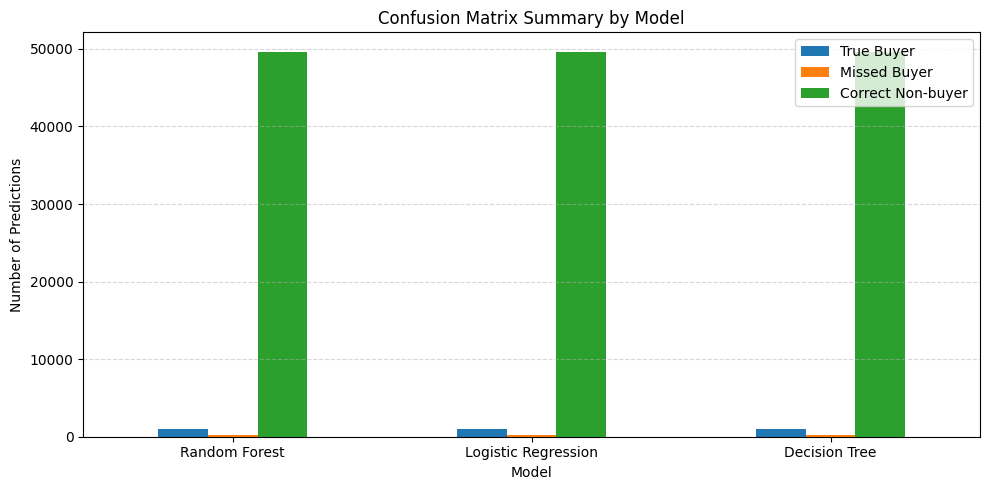

In [ ]:
confusion_summary.set_index("Model").plot(kind="bar", figsize=(10, 5))

plt.title("Confusion Matrix Summary by Model")
plt.xlabel("Model")
plt.ylabel("Number of Predictions")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("/content/final_report/images/confusion_matrix_summary.png", dpi=300)
plt.show()

## 16. Check Saved Figures

This final check confirms that all visualization files were saved in the image folder.  
The generated figures were later used in the final report and GitHub README.

In [ ]:
import os

os.listdir("/content/final_report/images")

['conversion_funnel.png',
 'behavior_distribution.png',
 'model_performance_comparison.png',
 'top10_purchase_categories.png',
 'confusion_matrix_summary.png',
 'buyer_nonbuyer_distribution.png',
 'hourly_user_activity.png']